# 🚆 Exploratory Analysis of Indian Railways Network: Station Traffic, Route Structure, and Scheduling Patterns

## 🎯 Objective
This project analyzes Indian Railways data (186,124 records across 12 columns) to understand station traffic, route structure, scheduling patterns, and overall network efficiency.

### 📂 Dataset Source
Dataset: Indian Railways Time Table for Trains Available for Reservation as on 01-11-2017

Source: Government of India Open Data Portal

Link: https://www.data.gov.in/resource/indian-railways-time-table-trains-available-reservation-01112017

Description: Contains train schedules, station stops, arrival and departure times, and route distance information.

## ❓ Problem Statement
Large-scale transportation networks often exhibit uneven load distribution, where a small number of stations and routes handle a disproportionate share of traffic. This creates efficiency in routing but increases vulnerability to disruptions.

This project examines:
- Distribution of train traffic across stations
- Route efficiency based on distance and stops
- Scheduling patterns and peak hours
- Dependency on major hubs

The goal is to identify how traffic and connectivity are distributed across the network, and whether the system is balanced or heavily centralized around a few critical nodes.

In [1]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading and Overview

In [2]:
# LOAD DATASET

df = pd.read_csv("../data/Train_details_22122017.csv", low_memory=False)

print('Shape:', df.shape)
print('\nColumn Names:')
print(df.columns.tolist())

Shape: (186124, 12)

Column Names:
['Train No', 'Train Name', 'SEQ', 'Station Code', 'Station Name', 'Arrival time', 'Departure Time', 'Distance', 'Source Station', 'Source Station Name', 'Destination Station', 'Destination Station Name']


In [3]:
# Basic info — dtypes and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 186124 entries, 0 to 186123
Data columns (total 12 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   Train No                  186124 non-null  str  
 1   Train Name                186124 non-null  str  
 2   SEQ                       186124 non-null  str  
 3   Station Code              186124 non-null  str  
 4   Station Name              186124 non-null  str  
 5   Arrival time              186119 non-null  str  
 6   Departure Time            186119 non-null  str  
 7   Distance                  186119 non-null  str  
 8   Source Station            186114 non-null  str  
 9   Source Station Name       186114 non-null  str  
 10  Destination Station       186114 non-null  str  
 11  Destination Station Name  186114 non-null  str  
dtypes: str(12)
memory usage: 17.0 MB


In [4]:
# Preview
df.head()

,Train No,Train Name,SEQ,Station Code,Station Name,Arrival time,Departure Time,Distance,Source Station,Source Station Name,Destination Station,Destination Station Name
0,107,SWV-MAO-VLNK,1,SWV,SAWANTWADI R,00:00:00,10:25:00,0,SWV,SAWANTWADI ROAD,MAO,MADGOAN JN.
1,107,SWV-MAO-VLNK,2,THVM,THIVIM,11:06:00,11:08:00,32,SWV,SAWANTWADI ROAD,MAO,MADGOAN JN.
2,107,SWV-MAO-VLNK,3,KRMI,KARMALI,11:28:00,11:30:00,49,SWV,SAWANTWADI ROAD,MAO,MADGOAN JN.
3,107,SWV-MAO-VLNK,4,MAO,MADGOAN JN.,12:10:00,00:00:00,78,SWV,SAWANTWADI ROAD,MAO,MADGOAN JN.
4,108,VLNK-MAO-SWV,1,MAO,MADGOAN JN.,00:00:00,20:30:00,0,MAO,MADGOAN JN.,SWV,SAWANTWADI ROAD


In [5]:
# Summary statistics
df.describe(include="all")

,Train No,Train Name,SEQ,Station Code,Station Name,Arrival time,Departure Time,Distance,Source Station,Source Station Name,Destination Station,Destination Station Name
count,186124,186124,186124,186124,186124,186119,186119,186119,186114,186114,186114,186114
unique,11113,7585,123,8151,8100,1443,1444,3101,926,921,928,923
top,53041,MSB-TBM EMU,1,CSMT,CST-MUMBAI,00:00:00,00:00:00,0,HWH,HOWRAH JN.,HWH,HOWRAH JN.
freq,118,2436,11112,1027,1027,2002,1969,11124,7977,7977,7840,7840


---
## 2. Data Cleaning & Preprocessing

In [6]:
# DATA CLEANING

# Count duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows: ",duplicate_count)

Number of duplicate rows:  0


In [7]:
# Check missing values 
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Train No                     0
Train Name                   0
SEQ                          0
Station Code                 0
Station Name                 0
Arrival time                 5
Departure Time               5
Distance                     5
Source Station              10
Source Station Name         10
Destination Station         10
Destination Station Name    10
dtype: int64


In [8]:
# dropping missing rows

df= df.dropna(subset=[
    'Arrival time',
    'Departure Time',
    'Distance',
    'Source Station',
    'Source Station Name',
    'Destination Station',
    'Destination Station Name'
])

print("Rows removed: ", 186124-df.shape[0])


Rows removed:  10


In [9]:
# Handle time columns 

#identify origin and destination stations
df['is_origin'] = df['Arrival time'] == '00:00:00'
df['is_destination'] = df['Departure Time']  == '00:00:00'

#replace fake time values 
df['Arrival time'] = df['Arrival time'].replace('00:00:00', np.nan)
df['Departure Time'] = df['Departure Time'].replace('00:00:00', np.nan)

#convert to datetime 
df['Arrival time'] = pd.to_datetime(df['Arrival time'], format='%H:%M:%S', errors='coerce')
df['Departure Time'] = pd.to_datetime(df['Departure Time'], format='%H:%M:%S', errors='coerce')

#Extract hour 
df['Arrival Hour'] = df['Arrival time'].dt.hour
df['Departure Hour'] = df['Departure Time'].dt.hour

print("Time columns parsed")
df.head()

Time columns parsed


,Train No,Train Name,SEQ,Station Code,Station Name,Arrival time,Departure Time,Distance,Source Station,Source Station Name,Destination Station,Destination Station Name,is_origin,is_destination,Arrival Hour,Departure Hour
0,107,SWV-MAO-VLNK,1,SWV,SAWANTWADI R,NaT,1900-01-01 10:25:00,0,SWV,SAWANTWADI ROAD,MAO,MADGOAN JN.,True,False,NaN,10.0
1,107,SWV-MAO-VLNK,2,THVM,THIVIM,1900-01-01 11:06:00,1900-01-01 11:08:00,32,SWV,SAWANTWADI ROAD,MAO,MADGOAN JN.,False,False,11.0,11.0
2,107,SWV-MAO-VLNK,3,KRMI,KARMALI,1900-01-01 11:28:00,1900-01-01 11:30:00,49,SWV,SAWANTWADI ROAD,MAO,MADGOAN JN.,False,False,11.0,11.0
3,107,SWV-MAO-VLNK,4,MAO,MADGOAN JN.,1900-01-01 12:10:00,NaT,78,SWV,SAWANTWADI ROAD,MAO,MADGOAN JN.,False,True,12.0,NaN
4,108,VLNK-MAO-SWV,1,MAO,MADGOAN JN.,NaT,1900-01-01 20:30:00,0,MAO,MADGOAN JN.,SWV,SAWANTWADI ROAD,True,False,NaN,20.0


In [10]:
# Ensure Distance is numeric 

df['Distance'] = pd.to_numeric(df['Distance'], errors= 'coerce')
df.dropna(subset=['Distance'], inplace=True)

print('Distance column cleaned ')
print('Final shape:', df.shape)

Distance column cleaned 
Final shape: (186114, 16)


---
## 3. Busiest Railway Stations
**Which stations have the most train stops?**

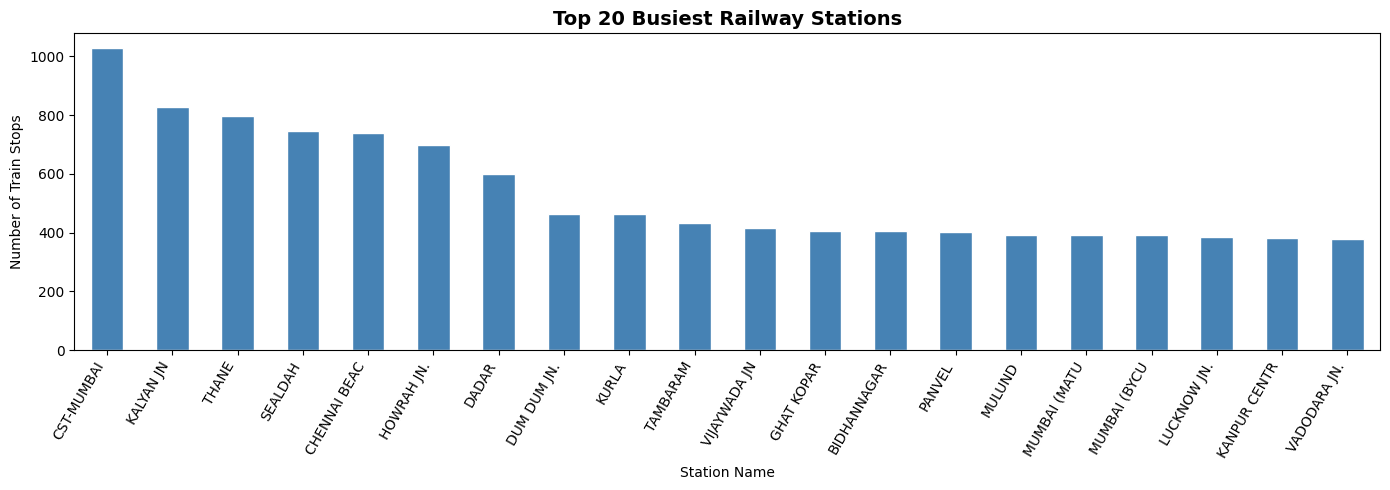


Top 5 Busiest Stations:
Station Name
CST-MUMBAI      1027
KALYAN JN        828
THANE            796
SEALDAH          745
CHENNAI BEAC     738
Name: Train No, dtype: int64


In [11]:
#df.groupby('Station Name')['Train No'].nunique()
busiest_stations = df.groupby('Station Name')['Train No'].nunique().sort_values(ascending=False).head(20)

plt.figure(figsize=(14, 5))
busiest_stations.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 20 Busiest Railway Stations', fontsize=14, fontweight='bold')
plt.xlabel('Station Name')
plt.ylabel('Number of Train Stops')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

print('\nTop 5 Busiest Stations:')
print(busiest_stations.head())

Train traffic is highly concentrated, with CST-Mumbai, Kalyan Junction and Thane handling the highest number of unique trains. This strong centralization around a few metro stations means the network is heavily dependent on these hubs — any disruption here would impact a large portion of overall operations.

---
## 4. Train Route Structure Analysis
**How many stops does each train make?**

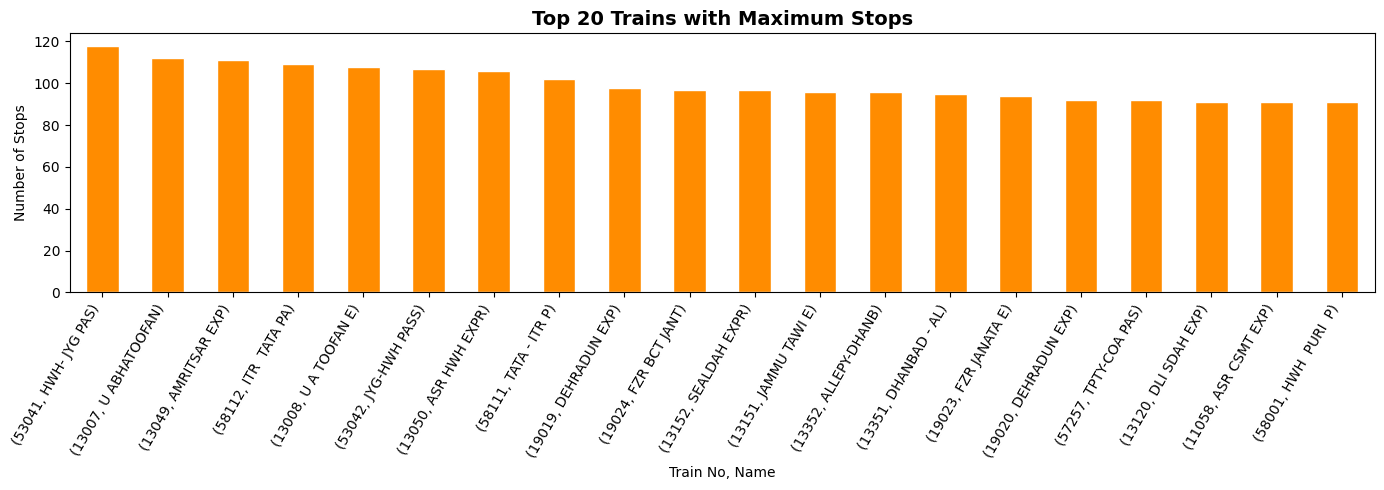


Top 5 Trains with Maximum Stops:
Train No  Train Name  
53041     HWH- JYG PAS    118
13007     U ABHATOOFAN    112
13049     AMRITSAR EXP    111
58112     ITR  TATA PA    109
13008     U A TOOFAN E    108
Name: Station Name, dtype: int64


In [12]:
# Count stations per train = number of stops

#stops_per_train = df.groupby('Train No')['Station Name'].count()
stops_per_train = df.groupby(['Train No', 'Train Name'])['Station Name'].nunique()

top_trains = stops_per_train.sort_values(ascending=False).head(20)

plt.figure(figsize=(14, 5))
top_trains.plot(kind='bar', color='darkorange', edgecolor='white')
plt.title('Top 20 Trains with Maximum Stops', fontsize=14, fontweight='bold')
plt.xlabel('Train No, Name')
plt.ylabel('Number of Stops')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

print('\nTop 5 Trains with Maximum Stops:')
print(top_trains.head())

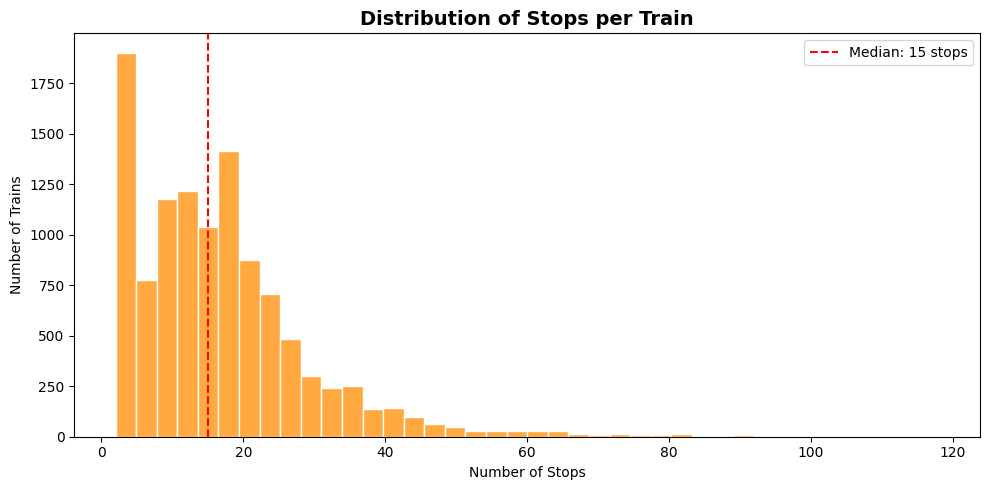

Mean stops  : 16.7
Median stops: 15
Max stops   : 118


In [13]:
# Distribution of stops across all trains
plt.figure(figsize=(10, 5))
sns.histplot(stops_per_train, bins=40, color='darkorange', edgecolor='white')
plt.axvline(stops_per_train.median(), color='red', linestyle='--',
            label=f'Median: {stops_per_train.median():.0f} stops')
plt.title('Distribution of Stops per Train', fontsize=14, fontweight='bold')
plt.xlabel('Number of Stops')
plt.ylabel('Number of Trains')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean stops  : {stops_per_train.mean():.1f}")
print(f"Median stops: {stops_per_train.median():.0f}")
print(f"Max stops   : {stops_per_train.max()}")

The distribution is right-skewed, with most trains having 10–20 stops. The mean (16.7) is higher than the median (15), indicating a few long-distance trains with very high stops (up to 118). This shows that while most routes are moderate, some trains cover extensive networks and play a key role in connectivity.

---
## 5. Train Route Distance Analysis
**Which trains cover the longest distances?**

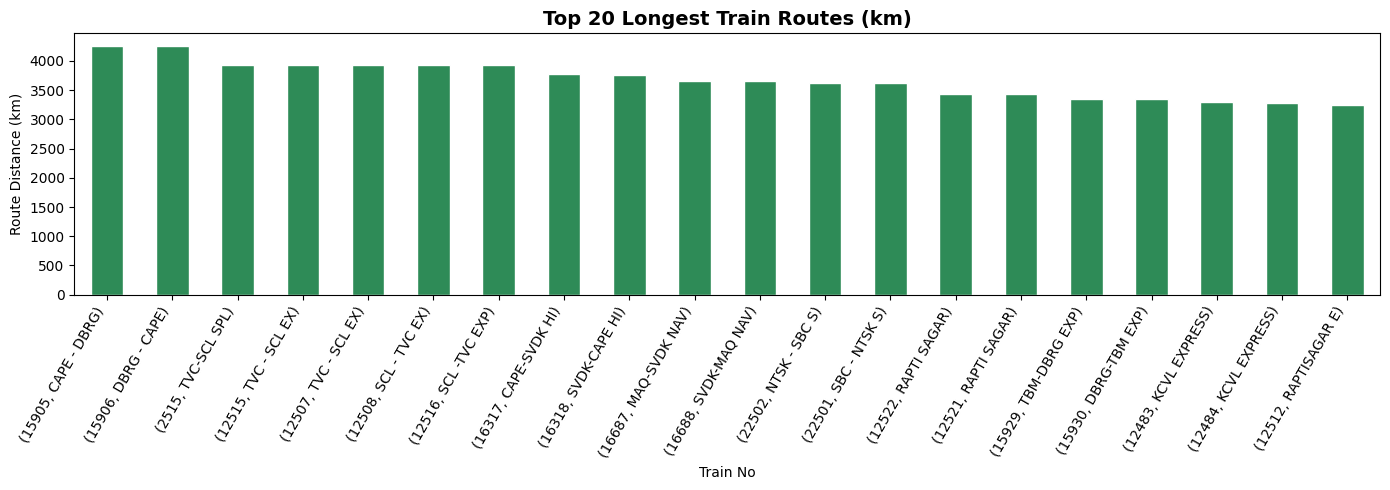


Top 5 longest train routes (in km):
Train No  Train Name  
15905     CAPE - DBRG     4260
15906     DBRG - CAPE     4256
2515      TVC-SCL SPL     3939
12515     TVC - SCL EX    3932
12507     TVC - SCL EX    3932
Name: Distance, dtype: int64


In [14]:
# Distance is cumulative from source — max(Distance) per train = total route length
distance_per_train = df.groupby(['Train No', 'Train Name'])['Distance'].max()

longest_routes = distance_per_train.sort_values(ascending=False).head(20)

plt.figure(figsize=(14, 5))
longest_routes.plot(kind='bar', color='seagreen', edgecolor='white')
plt.title('Top 20 Longest Train Routes (km)', fontsize=14, fontweight='bold')
plt.xlabel('Train No')
plt.ylabel('Route Distance (km)')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

# Print top 5
print('\nTop 5 longest train routes (in km):')
print(longest_routes.head())

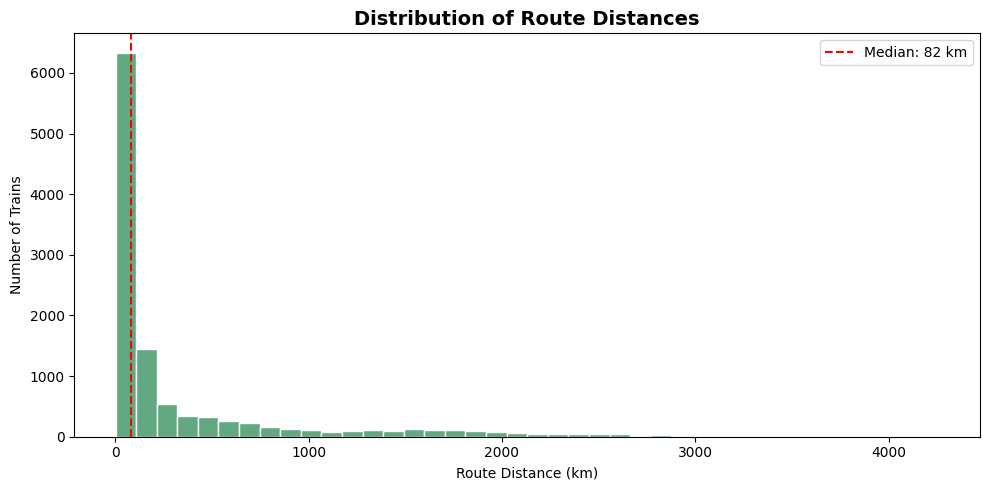

Mean distance  : 349 km
Median distance: 82 km
Max distance   : 4,260 km


In [15]:
# Distance distribution across all trains
plt.figure(figsize=(10, 5))
sns.histplot(distance_per_train, bins=40, color='seagreen', edgecolor='white')
plt.axvline(distance_per_train.median(), color='red', linestyle='--',
            label=f'Median: {distance_per_train.median():.0f} km')
plt.title('Distribution of Route Distances', fontsize=14, fontweight='bold')
plt.xlabel('Route Distance (km)')
plt.ylabel('Number of Trains')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean distance  : {distance_per_train.mean():,.0f} km")
print(f"Median distance: {distance_per_train.median():,.0f} km")
print(f"Max distance   : {distance_per_train.max():,} km")


Most train routes fall within a moderate distance range, with the majority of trains covering under 1,000 km. Only a few routes extend to very long distances, reflecting a network that balances widespread regional connectivity with select long-haul intercity services.

---
## 6. Station Connectivity Analysis
**Which stations are served by the most unique trains?**

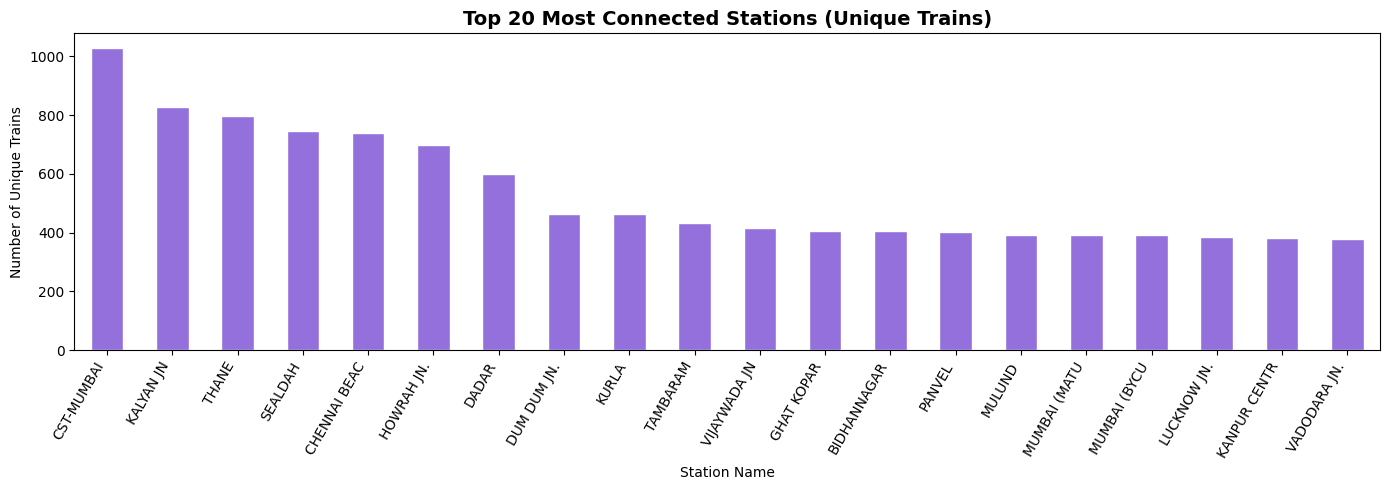


Top 5 Most Connected Stations:
Station Name
CST-MUMBAI      1027
KALYAN JN        828
THANE            796
SEALDAH          745
CHENNAI BEAC     738
Name: Train No, dtype: int64


In [16]:
# Count unique trains per station
connectivity = df.groupby('Station Name')['Train No'].nunique().sort_values(ascending=False).head(20)

plt.figure(figsize=(14, 5))
connectivity.plot(kind='bar', color='mediumpurple', edgecolor='white')
plt.title('Top 20 Most Connected Stations (Unique Trains)', fontsize=14, fontweight='bold')
plt.xlabel('Station Name')
plt.ylabel('Number of Unique Trains')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

print('\nTop 5 Most Connected Stations:')
print(connectivity.head())

Certain stations are connected to a disproportionately large number of unique trains, making them critical interchange nodes in the network. Their high connectivity means passengers passing through these stations have significantly more routing options compared to smaller stations.

---
## 7. Source–Destination Route Analysis
**What are the most common origin–destination pairs?**

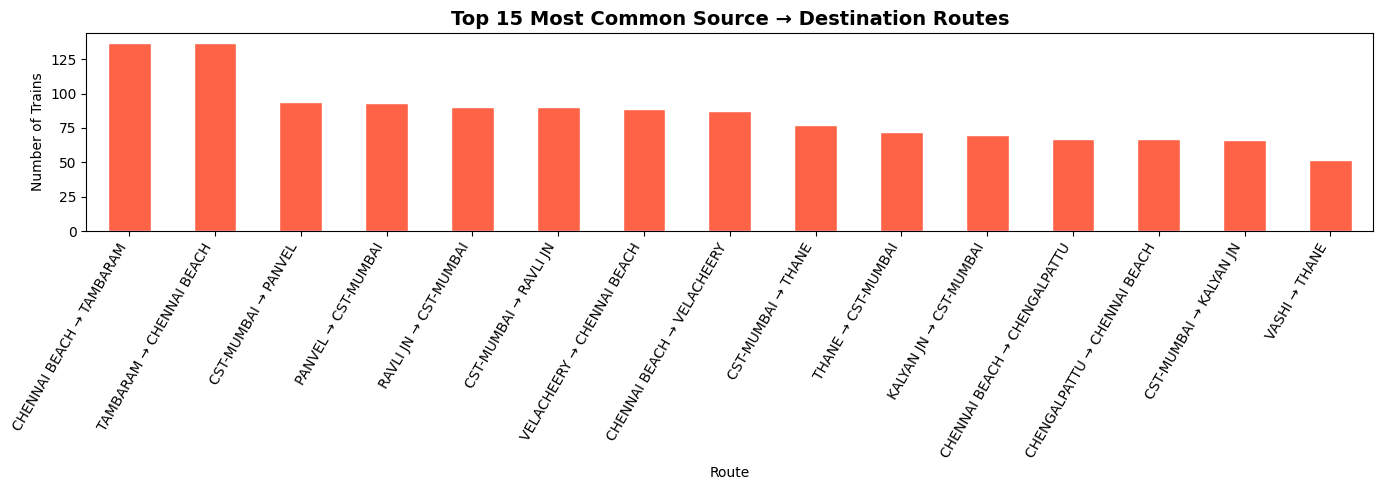


Top 5 Most Common Routes:
Route
CHENNAI BEACH → TAMBARAM    137
TAMBARAM → CHENNAI BEACH    137
CST-MUMBAI → PANVEL          94
PANVEL → CST-MUMBAI          93
RAVLI JN → CST-MUMBAI        90
Name: count, dtype: int64


In [17]:
# Create a Route column combining Source and Destination
df['Route'] = df['Source Station Name'] + ' → ' + df['Destination Station Name']
# Each train has one fixed route — count unique trains per route
top_routes = (
    df[['Train No', 'Route']]
    .drop_duplicates()
    ['Route']
    .value_counts()
    .head(15)
)

plt.figure(figsize=(14, 5))
top_routes.plot(kind='bar', color='tomato', edgecolor='white')
plt.title('Top 15 Most Common Source → Destination Routes', fontsize=14, fontweight='bold')
plt.xlabel('Route')
plt.ylabel('Number of Trains')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

print('\nTop 5 Most Common Routes:')
print(top_routes.head())

The most common routes are Chennai Beach → Tambaram and its reverse (137 trains each), followed by CST-Mumbai → Panvel (94 trains). These are predominantly suburban commuter corridors rather than long-distance intercity routes, revealing that high-frequency short-distance services dominate the route count. A few key urban corridors concentrate a large share of total train operations.

---
## 8. Scheduling Pattern Analysis
**At what hours do trains arrive and depart most frequently?**

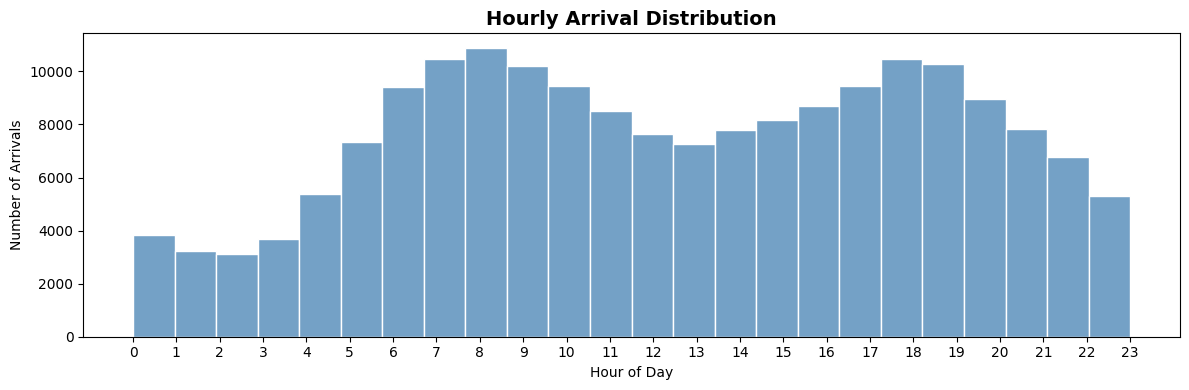

In [18]:
# Arrival hour distribution 
plt.figure(figsize=(12, 4))
sns.histplot(df['Arrival Hour'].dropna(), bins=24, color='steelblue', edgecolor='white')
plt.title('Hourly Arrival Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Arrivals')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

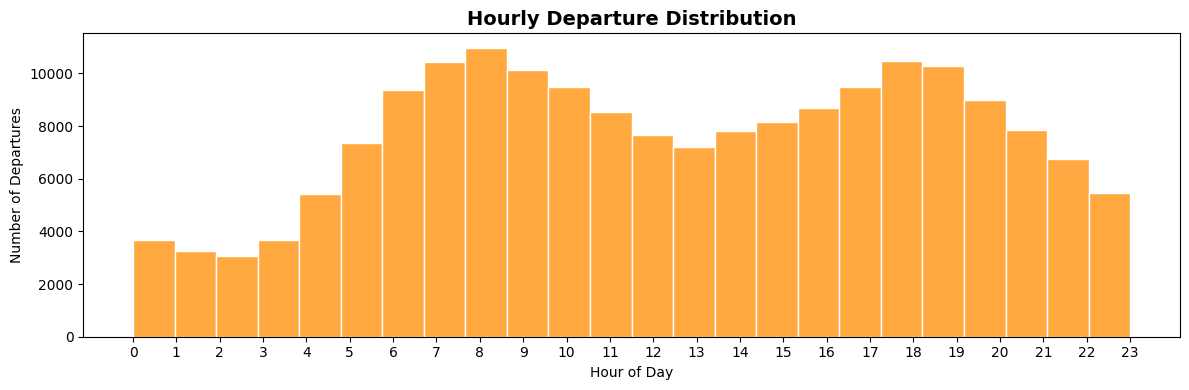

Peak arrival hour  : 08:00
Peak departure hour: 08:00


In [19]:
# Departure hour distribution
plt.figure(figsize=(12, 4))
sns.histplot(df['Departure Hour'].dropna(), bins=24, color='darkorange', edgecolor='white')
plt.title('Hourly Departure Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Departures')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

peak_arr = df['Arrival Hour'].dropna().astype(int).value_counts().idxmax()
peak_dep = df['Departure Hour'].dropna().astype(int).value_counts().idxmax()
print(f'Peak arrival hour  : {peak_arr:02d}:00')
print(f'Peak departure hour: {peak_dep:02d}:00')

Both peak arrival and departure activity occurs at 08:00, indicating that early morning is the busiest period across the network. Activity remains elevated through the evening hours (18:00–21:00), reflecting a combination of morning commutes and overnight long-distance journeys that dominate Indian Railways scheduling.

---
## 9. Distance vs. Stops Relationship
**Do longer routes always have more stops?**

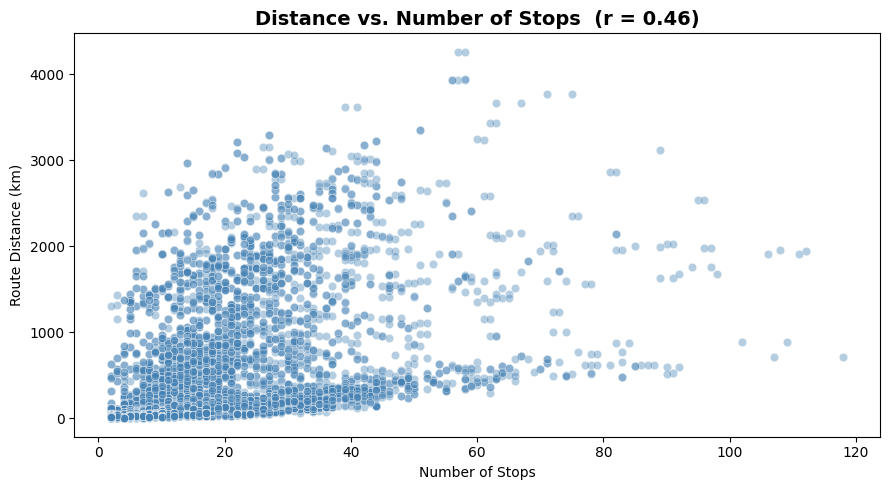

Correlation: 0.46


In [20]:
# Combine stops and distance
merged = pd.concat([stops_per_train, distance_per_train], axis=1)
merged.columns = ['Stops', 'Distance']
merged = merged.dropna()

# Correlation
corr = merged['Stops'].corr(merged['Distance'])

plt.figure(figsize=(9, 5))
sns.scatterplot(x='Stops', y='Distance', data=merged, alpha=0.4, color='steelblue')
plt.title(f'Distance vs. Number of Stops  (r = {corr:.2f})', fontsize=14, fontweight='bold')
plt.xlabel('Number of Stops')
plt.ylabel('Route Distance (km)')
plt.tight_layout()
plt.show()

print(f'Correlation: {corr:.2f}')

There is a moderate positive correlation (r = 0.46) between distance and stops, meaning longer routes generally have more stops. However, the wide scatter in the chart shows many exceptions — some trains cover very long distances with surprisingly few stops, indicating express-style operations on those routes.

---
## 10. Critical Railway Hubs & Network Dependence
**Do a small number of stations handle most of the network traffic?**

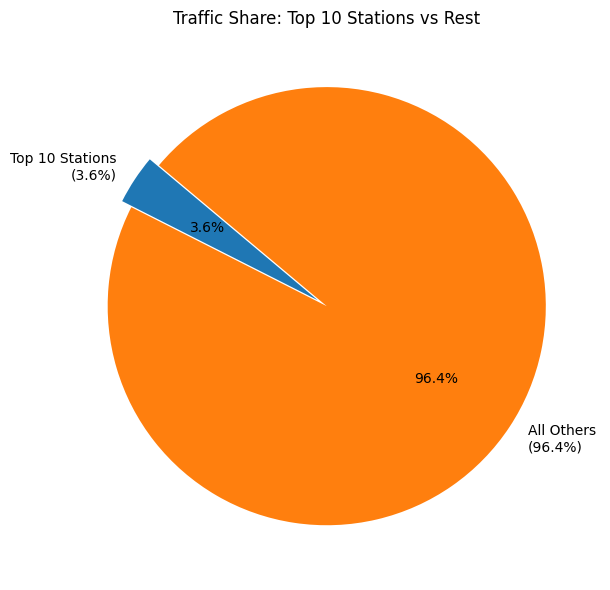

In [21]:
station_counts = df['Station Name'].value_counts()

top10_stops = station_counts.head(10).sum()
total_stops = station_counts.sum()

labels = [
    f'Top 10 Stations\n({top10_stops/total_stops*100:.1f}%)',
    f'All Others\n({(total_stops-top10_stops)/total_stops*100:.1f}%)'
]

sizes = [top10_stops, total_stops - top10_stops]

plt.figure(figsize=(7, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%',
        startangle=140, explode=[0.05, 0])

plt.title('Traffic Share: Top 10 Stations vs Rest')
plt.tight_layout()
plt.show()

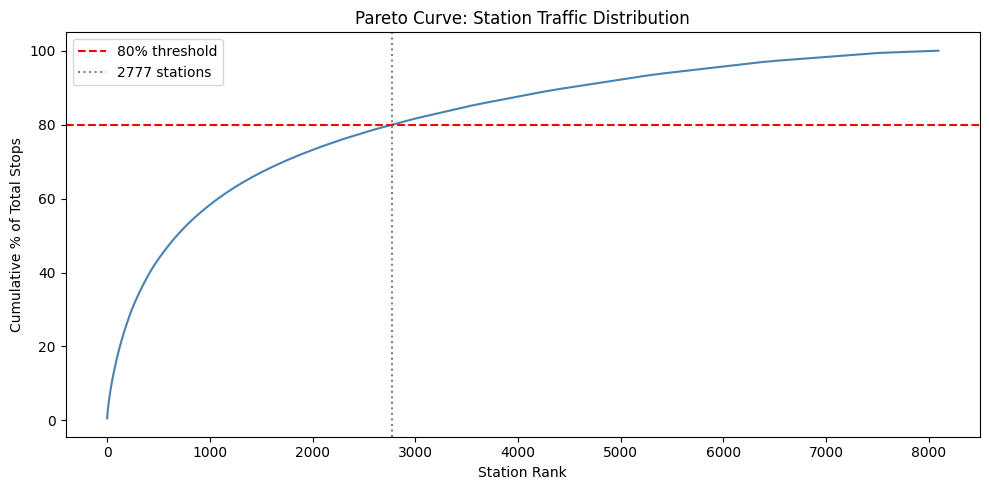

2777 stations account for 80% of total traffic


In [22]:
# Station traffic counts
station_counts = df['Station Name'].value_counts().reset_index()
station_counts.columns = ['Station', 'Stops']

# Cumulative percentage
station_counts['cumulative_pct'] = station_counts['Stops'].cumsum() / station_counts['Stops'].sum() * 100

# Find how many stations make up 80% traffic
n_80 = (station_counts['cumulative_pct'] <= 80).sum() + 1

# Plot
plt.figure(figsize=(10, 5))
plt.plot(station_counts['cumulative_pct'], color='steelblue')

plt.axhline(80, color='red', linestyle='--', label='80% threshold')
plt.axvline(n_80, color='grey', linestyle=':', label=f'{n_80} stations')

plt.title('Pareto Curve: Station Traffic Distribution')
plt.xlabel('Station Rank')
plt.ylabel('Cumulative % of Total Stops')

plt.legend()
plt.tight_layout()
plt.show()

print(f'{n_80} stations account for 80% of total traffic')

The Pareto curve shows that just 2,777 stations out of 8,000+ account for 80% of total train traffic. The pie chart further confirms that the top 10 stations alone handle 3.6% of all stops — a small but disproportionate share. This indicates the network is heavily centralized, with the majority of stations playing a minor role in overall traffic.

---
## 11. Route Efficiency Analysis
**Which trains cover more km per stop (express-like) vs fewer km per stop (local-like)?**

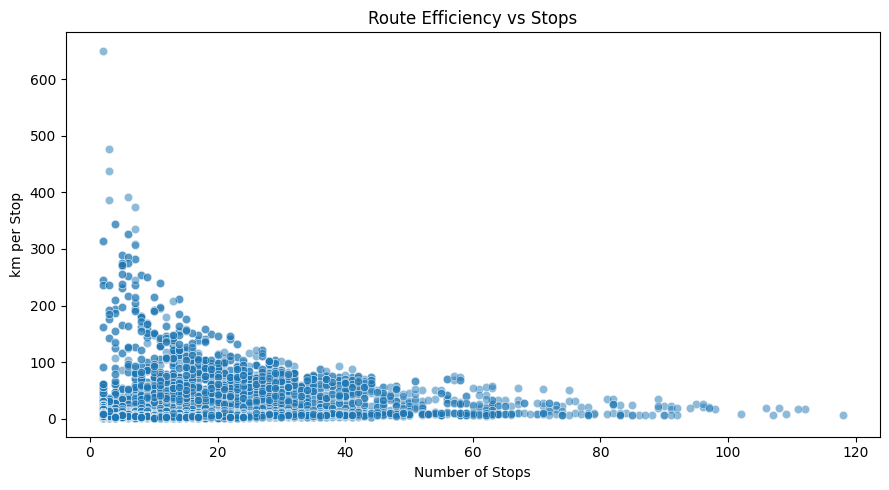

Average efficiency: 20.276628907469348


In [23]:
# Calculate efficiency
merged['Efficiency'] = merged['Distance'] / merged['Stops']

# Plot
plt.figure(figsize=(9, 5))
sns.scatterplot(x='Stops', y='Efficiency', data=merged, alpha=0.5)

plt.title('Route Efficiency vs Stops')
plt.xlabel('Number of Stops')
plt.ylabel('km per Stop')

plt.tight_layout()
plt.show()

# Basic stats
print("Average efficiency:", merged['Efficiency'].mean())

The average efficiency is 20.28 km per stop. Trains with fewer stops have much higher efficiency, meaning they skip stations and cover more ground — these are your express trains. Trains with more stops cluster near zero efficiency, which are the slow local trains that halt at every station. Simply put, the more stops a train makes, the less distance it covers between each one.

---
## 12. Station Hub Classification
**Classifying stations into High, Medium, Low traffic tiers.**

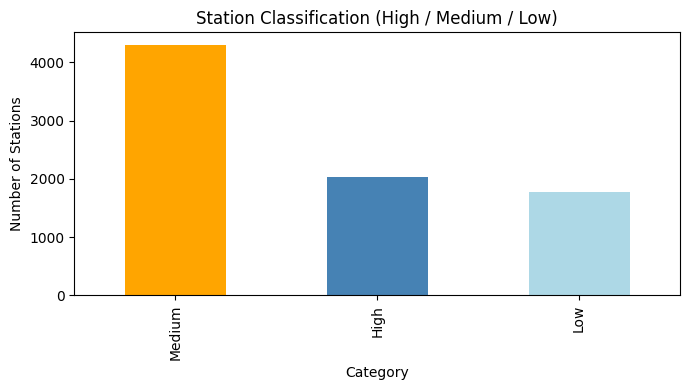

count
Medium    4301
High      2027
Low       1768
Name: count, dtype: int64


In [24]:
# Station traffic
station_counts = df['Station Name'].value_counts()

# Define thresholds
q25 = station_counts.quantile(0.25)
q75 = station_counts.quantile(0.75)

# Classify stations
def classify(x):
    if x >= q75:
        return 'High'
    elif x >= q25:
        return 'Medium'
    else:
        return 'Low'

hub_class = station_counts.apply(classify)

class_counts = hub_class.value_counts()

# Plot
plt.figure(figsize=(7, 4))
class_counts.plot(kind='bar', color=['orange', 'steelblue', 'lightblue'])

plt.title('Station Classification (High / Medium / Low)')
plt.xlabel('Category')
plt.ylabel('Number of Stations')

plt.tight_layout()
plt.show()

print(class_counts)

The majority of stations (4,301) fall into the Medium traffic tier, while High traffic stations number 2,027 and Low traffic stations 1,768. This means the network is not purely hub-dominated — a large middle layer of moderately active stations provides the connective tissue between major hubs and minor stops. Only a fraction of stations qualify as true high-traffic hubs.

---
## 13. Station Role Analysis
**Major Origin and Destination Hubs**

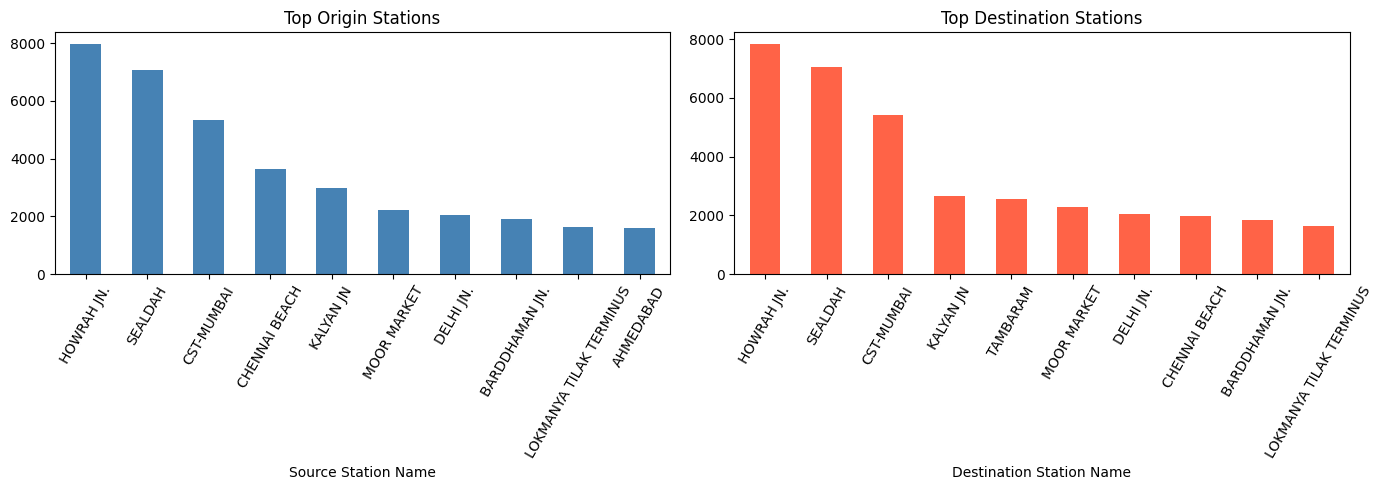

In [25]:
# Top origin stations
origin_counts = df['Source Station Name'].value_counts().head(10)

# Top destination stations
destination_counts = df['Destination Station Name'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

origin_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top Origin Stations')
axes[0].tick_params(axis='x', rotation=60)

destination_counts.plot(kind='bar', ax=axes[1], color='tomato')
axes[1].set_title('Top Destination Stations')
axes[1].tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.show()

Howrah Junction and Sealdah dominate as both top origin and destination stations, followed closely by CST-Mumbai and Chennai Beach. The near-identical pattern across both charts confirms that traffic flows are strongly bidirectional — the same major cities send and receive the highest volumes of trains, making them the true terminal anchors of the Indian Railways network.

---
## 14. Key Insights

1. **A few stations dominate the network.** CST-Mumbai leads with 1,027 unique trains, and just 2,777 stations account for 80% of total network traffic.

2. **Stop counts are right-skewed.** Most trains make 10–20 stops, but the top train (HWH-JYG PAS) makes 118 stops. Mean (16.7) is higher than median (15), showing a few outliers pulling the distribution.

3. **Route distances vary widely.** The median route is just 82 km, but the longest route (CAPE-DBRG) covers 4,260 km — showing the network serves both local commuters and long-distance travellers.

4. **Distance and stops are moderately related.** A correlation of r = 0.46 confirms longer routes tend to have more stops, but many exceptions exist — particularly express trains.

5. **Peak activity occurs at 08:00.** Both arrivals and departures peak at 8 AM, with a secondary surge between 18:00–21:00, reflecting commuter and overnight travel patterns.

6. **Suburban corridors dominate route frequency.** Chennai Beach → Tambaram (137 trains) and CST-Mumbai → Panvel (94 trains) are the busiest routes — short-distance commuter lines, not intercity.

7. **Traffic flows are bidirectional.** Howrah Junction and Sealdah appear as both top origin and destination stations, confirming that major hubs anchor both ends of high-demand corridors.

---
## 15. Conclusion

This analysis of the Indian Railways dataset highlights a large and complex network with significant variation in route structures, station connectivity, and train operations.

The network shows partial centralization, with a few key stations handling a large share of traffic, while still maintaining widespread connectivity through frequent stops. Train routes vary widely in both distance and number of stops, reflecting a mix of local and long-distance services.

Overall, the analysis provides insights into traffic distribution, route efficiency, and scheduling patterns, which are essential for understanding the structure and behavior of the railway network.

---
*Analysis completed using Python · Pandas · Matplotlib · Seaborn*